# Tema 7 — Aspectos Avanzados: representaciones, transferencia, auto-supervisión y GANs

**Repositorio:** `deep-learning-complete-guide`  
**Asignatura:** Aprendizaje Automático II  
**Bloque:** aprendizaje de representaciones, transfer learning, multi-task learning, self-supervised learning, domain adaptation y modelos generativos adversarios

Este notebook resume el Tema 7 con un enfoque didáctico, práctico y orientado a examen. El objetivo es conectar la teoría con ejemplos de código sencillos, de forma que puedas entender qué se aprende en las capas internas de una red profunda y cómo se reutilizan esas representaciones en tareas avanzadas.

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Cómo usar este notebook

Este notebook está pensado para tres usos:

- **Estudiar teoría:** cada bloque resume las ideas fundamentales del tema.
- **Practicar con código:** se incluyen ejemplos mínimos en PyTorch y NumPy para entender los conceptos.
- **Publicarlo en GitHub:** el código usa datos sintéticos, evita rutas locales y es reproducible.

En este tema no todo se reduce a calcular parámetros o shapes. Lo importante es entender **qué representación aprende una red**, **cómo se reutiliza** y **cómo se entrena cuando no tenemos etiquetas directas**.

</div>

## Índice

1. Qué es una representación aprendida  
2. Representaciones jerárquicas en redes profundas  
3. Transfer Learning  
4. Multi-task Learning  
5. Self-supervised Learning  
6. Contrastive Learning  
7. Domain Adaptation  
8. Modelos generativos y variables latentes  
9. GANs: generador, discriminador y entrenamiento min-max  
10. Problemas de las GANs y Wasserstein GAN  
11. DCGAN y GANs condicionadas  
12. Ejercicios tipo examen resueltos

# 1. ¿Qué es una representación?

Una **representación** es una forma de transformar un dato original en otro espacio donde cierta información importante queda más explícita.

En Deep Learning, una representación suele ser el vector de activaciones de una capa interna de una red. Por ejemplo, en una CNN entrenada en ImageNet:

- las primeras capas pueden detectar bordes, colores o texturas;
- las capas intermedias pueden responder a partes de objetos;
- las capas profundas pueden codificar conceptos más abstractos;
- una capa fully connected final puede actuar como descriptor o *embedding* de la imagen.

En vez de comparar imágenes píxel a píxel, se comparan sus representaciones internas.

<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Idea clave

Una red profunda no solo aprende a producir una etiqueta. Durante el entrenamiento también construye una **representación interna** del problema.

Esa representación puede reutilizarse después para otras tareas, como clasificación con pocos datos, búsqueda de imágenes similares, detección, segmentación o adaptación a otro dominio.

</div>

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import TensorDataset, DataLoader
    torch.manual_seed(RANDOM_STATE)
    TORCH_AVAILABLE = True
except Exception as e:
    TORCH_AVAILABLE = False
    print("PyTorch no está disponible en este entorno:", e)

# 2. Representaciones jerárquicas profundas

Las redes profundas aprenden representaciones organizadas en varios niveles. Esta es una de las razones por las que funcionan tan bien en visión, lenguaje y otros problemas complejos.

Una posible interpretación en imágenes es:

| Nivel de la red | Qué suele aprender |
|---|---|
| Capas iniciales | bordes, cambios de color, texturas simples |
| Capas intermedias | patrones, formas, partes de objetos |
| Capas profundas | objetos completos o conceptos semánticos |
| Clasificador final | separación entre clases |

Esta jerarquía permite que una red reutilice patrones simples para construir conceptos más complejos.

## 2.1 Ejemplo sintético: un espacio de representación

Vamos a simular un espacio latente 2D en el que muestras de la misma clase quedan cerca y muestras de clases distintas quedan lejos.

En redes reales, este espacio puede tener cientos o miles de dimensiones. Por ejemplo, una capa fully connected de 4096 unidades puede actuar como descriptor de una imagen.

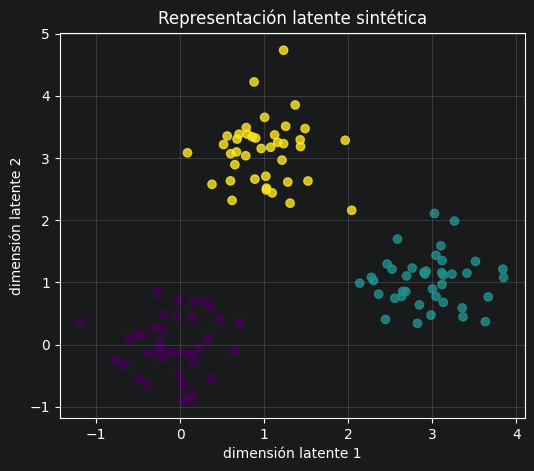

In [2]:
# Simulación de embeddings 2D para tres clases
centers = np.array([[0, 0], [3, 1], [1, 3]])
points = []
labels = []

for class_id, center in enumerate(centers):
    pts = center + 0.45 * np.random.randn(40, 2)
    points.append(pts)
    labels.extend([class_id] * len(pts))

X_emb = np.vstack(points)
y_emb = np.array(labels)

plt.figure(figsize=(6, 5))
plt.scatter(X_emb[:, 0], X_emb[:, 1], c=y_emb, alpha=0.8)
plt.title("Representación latente sintética")
plt.xlabel("dimensión latente 1")
plt.ylabel("dimensión latente 2")
plt.grid(True, alpha=0.3)
plt.show()

En este ejemplo, el espacio latente ya está organizado: las muestras de la misma clase aparecen próximas. En una red profunda, esta organización emerge durante el entrenamiento gracias a la función de pérdida y a la arquitectura.

<div style="background:rgba(191,144,0,0.14);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Cuidado de examen

Una representación aprendida depende de la tarea con la que se entrena el modelo.

- Si se entrena con una tarea **supervisada**, la representación tiende a estar muy orientada a separar las clases disponibles.
- Si se entrena con una tarea **auto-supervisada** o **no supervisada**, la representación puede ser más general y reutilizable.

</div>

# 3. Transfer Learning

El **aprendizaje por transferencia** consiste en reutilizar una representación aprendida en una tarea origen para resolver otra tarea destino.

Ejemplo típico:

1. Entrenar una CNN grande en ImageNet.
2. Quitar la última capa de clasificación.
3. Usar las capas previas como extractor de características.
4. Añadir una nueva cabeza de clasificación para la tarea concreta.

Esto es útil cuando la tarea destino tiene pocos datos.

## 3.1 Dos formas habituales

| Estrategia | Qué se hace | Cuándo usarla |
|---|---|---|
| Feature extraction | Congelar el backbone y entrenar solo la cabeza final | pocos datos y tarea parecida |
| Fine-tuning | Partir de pesos preentrenados y actualizar parte o todo el modelo | más datos o tarea menos parecida |

En ambos casos, el backbone actúa como representación general aprendida previamente.

In [3]:
if TORCH_AVAILABLE:
    class TinyBackbone(nn.Module):
        def __init__(self):
            super().__init__()
            self.features = nn.Sequential(
                nn.Linear(4, 16),
                nn.ReLU(),
                nn.Linear(16, 8),
                nn.ReLU()
            )

        def forward(self, x):
            return self.features(x)

    class TransferModel(nn.Module):
        def __init__(self, backbone, num_classes=3):
            super().__init__()
            self.backbone = backbone
            self.classifier = nn.Linear(8, num_classes)

        def forward(self, x):
            z = self.backbone(x)
            return self.classifier(z)

    backbone = TinyBackbone()
    model = TransferModel(backbone, num_classes=3)

    # Feature extraction: congelamos el backbone
    for param in model.backbone.parameters():
        param.requires_grad = False

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())

    print(model)
    print(f"Parámetros totales: {total}")
    print(f"Parámetros entrenables tras congelar backbone: {trainable}")
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

TransferModel(
  (backbone): TinyBackbone(
    (features): Sequential(
      (0): Linear(in_features=4, out_features=16, bias=True)
      (1): ReLU()
      (2): Linear(in_features=16, out_features=8, bias=True)
      (3): ReLU()
    )
  )
  (classifier): Linear(in_features=8, out_features=3, bias=True)
)
Parámetros totales: 243
Parámetros entrenables tras congelar backbone: 27


## 3.2 Fine-tuning

Para hacer *fine-tuning*, se vuelven a activar los gradientes de algunas capas del backbone.

En práctica:

- se suele usar un learning rate más bajo para las capas preentrenadas;
- se entrena más fuerte la nueva cabeza final;
- se evita destruir una representación útil ya aprendida.

In [4]:
if TORCH_AVAILABLE:
    # Descongelamos la última capa del backbone para fine-tuning parcial
    for name, param in model.backbone.named_parameters():
        param.requires_grad = name.startswith("features.2")

    # La cabeza final sigue siendo entrenable
    for param in model.classifier.parameters():
        param.requires_grad = True

    for name, param in model.named_parameters():
        print(f"{name:30s} requires_grad={param.requires_grad}")
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

backbone.features.0.weight     requires_grad=False
backbone.features.0.bias       requires_grad=False
backbone.features.2.weight     requires_grad=True
backbone.features.2.bias       requires_grad=True
classifier.weight              requires_grad=True
classifier.bias                requires_grad=True


<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Resumen de Transfer Learning

El transfer learning funciona porque muchas tareas comparten factores de variación. Por ejemplo, una red que aprende bordes, texturas y partes de objetos en una tarea puede reutilizar esas características en otra.

La parte importante no es solo el clasificador final, sino la **representación** construida por las capas anteriores.

</div>

# 4. Multi-task Learning

El **aprendizaje multi-tarea** entrena un mismo modelo para resolver varias tareas al mismo tiempo.

La idea es construir una representación compartida que sea útil para varias salidas. Por ejemplo, con una misma imagen de entrada:

- clasificar el objeto;
- estimar profundidad;
- estimar normales de superficie;
- detectar bordes;
- localizar puntos clave.

Si las tareas están relacionadas, pueden ayudarse entre sí. Si no lo están, puede aparecer **transferencia negativa**.

## 4.1 Arquitectura típica

Una arquitectura multi-tarea suele tener:

1. **Backbone compartido:** extrae una representación común.
2. **Cabeza de tarea 1:** por ejemplo, clasificación.
3. **Cabeza de tarea 2:** por ejemplo, regresión.
4. **Pérdida total:** combinación ponderada de las pérdidas de cada tarea.

$$
L_{total} = \lambda_1 L_1 + \lambda_2 L_2 + \dots + \lambda_T L_T
$$

In [5]:
if TORCH_AVAILABLE:
    class MultiTaskNet(nn.Module):
        def __init__(self, input_dim=6, hidden_dim=16, num_classes=3):
            super().__init__()
            self.shared = nn.Sequential(
                nn.Linear(input_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU()
            )
            self.class_head = nn.Linear(hidden_dim, num_classes)
            self.reg_head = nn.Linear(hidden_dim, 1)

        def forward(self, x):
            h = self.shared(x)
            logits = self.class_head(h)
            value = self.reg_head(h)
            return logits, value

    multitask_model = MultiTaskNet()
    x = torch.randn(8, 6)
    class_target = torch.randint(0, 3, (8,))
    reg_target = torch.randn(8, 1)

    logits, value = multitask_model(x)
    loss_class = F.cross_entropy(logits, class_target)
    loss_reg = F.mse_loss(value, reg_target)
    loss_total = loss_class + 0.5 * loss_reg

    print("logits shape:", logits.shape)
    print("regression output shape:", value.shape)
    print("loss clasificación:", round(loss_class.item(), 4))
    print("loss regresión:", round(loss_reg.item(), 4))
    print("loss total:", round(loss_total.item(), 4))
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

logits shape: torch.Size([8, 3])
regression output shape: torch.Size([8, 1])
loss clasificación: 1.1562
loss regresión: 1.3838
loss total: 1.8481


<div style="background:rgba(191,144,0,0.14);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Cuidado de examen

Multi-task learning no siempre mejora el rendimiento. Puede fallar si:

- las tareas no están relacionadas;
- una tarea domina el gradiente;
- las pérdidas tienen escalas muy diferentes;
- el backbone no tiene capacidad suficiente;
- las cabezas de salida se colocan en un punto inadecuado de la arquitectura.

</div>

# 5. Self-supervised Learning

El **aprendizaje auto-supervisado** entrena modelos usando etiquetas generadas automáticamente a partir de los propios datos.

No se parte de etiquetas humanas, sino de una tarea artificial o *pretext task*. El objetivo no suele ser resolver esa tarea en sí, sino aprender una buena representación.

Ejemplos clásicos:

- predecir la rotación aplicada a una imagen;
- reconstruir una zona oculta de una imagen (*inpainting*);
- colorear una imagen en escala de grises;
- ordenar fragmentos temporales de un vídeo;
- resolver un puzzle de parches;
- acercar dos vistas aumentadas de la misma imagen en un espacio latente.

## 5.1 Ejemplo simple: predecir una transformación

Supongamos que generamos una señal y le aplicamos una de varias transformaciones. La etiqueta no viene de una persona: la sabemos porque nosotros hemos aplicado la transformación.

Esto convierte datos no etiquetados en un problema supervisado artificial.

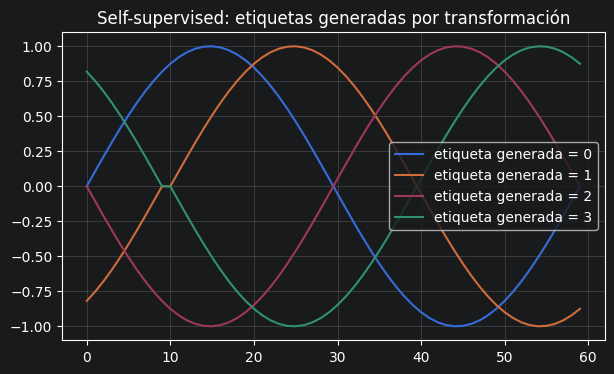

In [6]:
# Ejemplo conceptual de etiquetas generadas automáticamente
base_signal = np.sin(np.linspace(0, 2 * np.pi, 60))
transforms = {
    0: lambda x: x,
    1: lambda x: np.roll(x, 10),
    2: lambda x: -x,
    3: lambda x: np.roll(-x, 10),
}

plt.figure(figsize=(7, 4))
for label, transform in transforms.items():
    plt.plot(transform(base_signal), label=f"etiqueta generada = {label}")
plt.title("Self-supervised: etiquetas generadas por transformación")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

En imágenes, esta idea se aplica con transformaciones como rotaciones, recortes, colorización, predicción de parches o generación de vistas aumentadas.

# 6. Contrastive Learning

El **aprendizaje por contraste** aprende una representación acercando pares similares y alejando pares no similares.

En visión, una estrategia común es:

1. Tomar una imagen.
2. Generar dos vistas aumentadas de la misma imagen.
3. Pasarlas por una red.
4. Hacer que sus embeddings estén cerca.
5. Alejar embeddings de imágenes diferentes.

La idea básica es que dos versiones aumentadas del mismo dato deben tener una representación parecida.

## 6.1 Similitud coseno

Una medida habitual en contrastive learning es la similitud coseno:

$$
\text{sim}(u, v) = \frac{u \cdot v}{\|u\| \|v\|}
$$

Si dos vectores apuntan en la misma dirección, la similitud es alta.

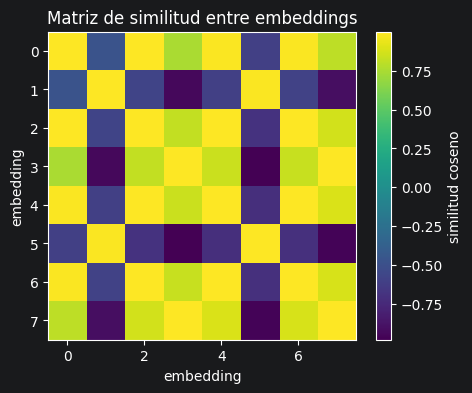

[[ 1.   -0.48  0.99  0.75  0.99 -0.6   0.99  0.8 ]
 [-0.48  1.   -0.57 -0.94 -0.6   0.99 -0.59 -0.91]
 [ 0.99 -0.57  1.    0.82  1.   -0.69  1.    0.86]
 [ 0.75 -0.94  0.82  1.    0.84 -0.98  0.83  1.  ]
 [ 0.99 -0.6   1.    0.84  1.   -0.72  1.    0.88]
 [-0.6   0.99 -0.69 -0.98 -0.72  1.   -0.71 -0.96]
 [ 0.99 -0.59  1.    0.83  1.   -0.71  1.    0.88]
 [ 0.8  -0.91  0.86  1.    0.88 -0.96  0.88  1.  ]]


In [7]:
def cosine_similarity_matrix(Z):
    Z_norm = Z / (np.linalg.norm(Z, axis=1, keepdims=True) + 1e-8)
    return Z_norm @ Z_norm.T

# Creamos 4 puntos base y dos vistas ligeramente perturbadas de cada uno
base = np.random.randn(4, 2)
view1 = base + 0.10 * np.random.randn(4, 2)
view2 = base + 0.10 * np.random.randn(4, 2)
Z = np.vstack([view1, view2])
S = cosine_similarity_matrix(Z)

plt.figure(figsize=(5, 4))
plt.imshow(S)
plt.colorbar(label="similitud coseno")
plt.title("Matriz de similitud entre embeddings")
plt.xlabel("embedding")
plt.ylabel("embedding")
plt.show()

print(np.round(S, 2))

## 6.2 Pérdida contrastiva tipo InfoNCE

Una forma simplificada de pérdida contrastiva para un par positivo $(i,j)$ es:

$$
L_i = -\log \frac{\exp(\text{sim}(z_i,z_j)/\tau)}{\sum_{k \neq i}\exp(\text{sim}(z_i,z_k)/\tau)}
$$

Donde $\tau$ es la temperatura. Una temperatura baja hace que las diferencias de similitud tengan más efecto.

In [8]:
if TORCH_AVAILABLE:
    def info_nce_loss(z, temperature=0.2):
        """Pérdida contrastiva para un batch con dos vistas por muestra.
        z tiene shape [2N, dim]. El positivo de i es i+N si i<N, si no i-N.
        """
        z = F.normalize(z, dim=1)
        sim = z @ z.T / temperature
        batch_size = z.shape[0]
        n = batch_size // 2

        # Quitamos similitud consigo mismo poniendo -inf en diagonal
        mask = torch.eye(batch_size, dtype=torch.bool)
        sim = sim.masked_fill(mask, -1e9)

        positives = torch.arange(batch_size)
        positives = (positives + n) % batch_size
        loss = F.cross_entropy(sim, positives)
        return loss

    z = torch.randn(8, 16)
    loss = info_nce_loss(z, temperature=0.2)
    print("InfoNCE loss:", round(loss.item(), 4))
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

InfoNCE loss: 2.5411


<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Resumen de Self-supervised Learning

El aprendizaje auto-supervisado busca explotar datos no etiquetados para aprender representaciones útiles. La clave no es la etiqueta artificial en sí, sino diseñar una tarea que obligue al modelo a capturar estructura relevante del dato.

El aprendizaje contrastivo es una de las estrategias más importantes: acerca representaciones de datos similares y aleja representaciones de datos distintos.

</div>

# 7. Domain Adaptation

La **adaptación de dominio** busca entrenar un modelo en un dominio fuente y aplicarlo en un dominio objetivo diferente.

Ejemplos:

- entrenar con imágenes sintéticas y aplicar a imágenes reales;
- entrenar con fotos de día y aplicar a fotos de noche;
- entrenar con una cámara y aplicar a otra;
- entrenar con un hospital y aplicar a otro.

El problema es que la distribución de entrada cambia.

## 7.1 Idea de Domain-Adversarial Training

Una estrategia consiste en aprender una representación que sea:

- útil para la tarea principal;
- difícil de distinguir entre dominio fuente y dominio objetivo.

Para ello se puede usar un clasificador de dominio adversario. El extractor de características intenta engañar al clasificador de dominio, de forma parecida a una GAN, pero aplicada a dominios.

In [9]:
if TORCH_AVAILABLE:
    class GradientReversal(torch.autograd.Function):
        @staticmethod
        def forward(ctx, x, lambd):
            ctx.lambd = lambd
            return x.view_as(x)

        @staticmethod
        def backward(ctx, grad_output):
            return -ctx.lambd * grad_output, None

    def grad_reverse(x, lambd=1.0):
        return GradientReversal.apply(x, lambd)

    class DomainAdversarialToy(nn.Module):
        def __init__(self):
            super().__init__()
            self.feature = nn.Sequential(nn.Linear(2, 8), nn.ReLU())
            self.label_head = nn.Linear(8, 2)
            self.domain_head = nn.Linear(8, 2)

        def forward(self, x, lambd=1.0):
            h = self.feature(x)
            y_logits = self.label_head(h)
            d_logits = self.domain_head(grad_reverse(h, lambd))
            return y_logits, d_logits

    model_da = DomainAdversarialToy()
    x = torch.randn(10, 2)
    y_logits, d_logits = model_da(x, lambd=0.5)

    print("salida tarea principal:", y_logits.shape)
    print("salida clasificador de dominio:", d_logits.shape)
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

salida tarea principal: torch.Size([10, 2])
salida clasificador de dominio: torch.Size([10, 2])


<div style="background:rgba(191,144,0,0.14);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Cuidado de examen

Domain adaptation no significa simplemente entrenar con más datos. El objetivo es manejar un cambio de distribución entre el dominio fuente y el dominio destino.

La representación ideal conserva la información útil para resolver la tarea, pero elimina o reduce la información que permite distinguir el dominio.

</div>

# 8. Modelos generativos y variables latentes

Un **modelo generativo** intenta modelar cómo se generan los datos. En vez de aprender solo una frontera de decisión, aprende a producir ejemplos plausibles.

Muchos modelos generativos usan variables latentes $z$:

$$
z \sim p(z)
$$

$$
x = g(z)
$$

Donde $z$ es un vector de menor dimensión y $g$ transforma ese vector en un dato generado.

En imágenes, $z$ puede representar factores ocultos como postura, iluminación, estilo, identidad o forma.

## 8.1 Qué se busca en un buen modelo generativo

| Propiedad | Significado |
|---|---|
| Muestreo eficiente | generar ejemplos con poco coste |
| Alta calidad | muestras realistas |
| Cobertura | representar toda la distribución de datos |
| Espacio latente coherente | cambios suaves en $z$ producen cambios suaves en $x$ |
| Espacio latente interpretable | direcciones de $z$ controlan propiedades comprensibles |
| Verosimilitud eficiente | si es probabilístico, calcular $p(x)$ debería ser viable |

No todos los modelos generativos cumplen todas estas propiedades igual de bien.

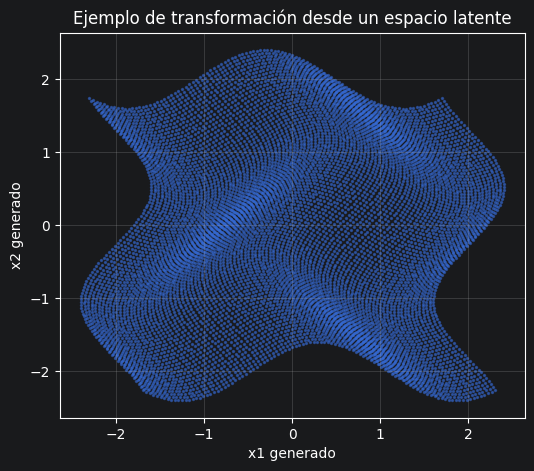

In [10]:
# Espacio latente 2D simple: z -> x mediante una transformación no lineal
z1 = np.linspace(-2, 2, 100)
z2 = np.linspace(-2, 2, 100)
Z1, Z2 = np.meshgrid(z1, z2)
X1 = Z1 + 0.4 * np.sin(2 * Z2)
X2 = Z2 + 0.4 * np.cos(2 * Z1)

plt.figure(figsize=(6, 5))
plt.scatter(X1.ravel(), X2.ravel(), s=2, alpha=0.5)
plt.title("Ejemplo de transformación desde un espacio latente")
plt.xlabel("x1 generado")
plt.ylabel("x2 generado")
plt.grid(True, alpha=0.3)
plt.show()

# 9. Generative Adversarial Networks: GANs

Una **GAN** tiene dos redes:

| Red | Objetivo |
|---|---|
| Generador $G$ | transformar ruido $z$ en datos falsos realistas |
| Discriminador $D$ | distinguir datos reales de datos generados |

El entrenamiento es adversario:

- el discriminador aprende a separar reales y generados;
- el generador aprende a engañar al discriminador.

El resultado ideal es que el generador produzca ejemplos tan realistas que el discriminador no pueda distinguirlos de los reales.

## 9.1 Función objetivo original

La formulación clásica puede escribirse como:

$$
\min_G \max_D V(D,G) =
\mathbb{E}_{x \sim p_{data}}[\log D(x)] +
\mathbb{E}_{z \sim p_z}[\log(1-D(G(z)))]
$$

El discriminador maximiza la probabilidad de clasificar correctamente reales y falsos. El generador intenta que $D(G(z))$ sea alto, es decir, que sus muestras parezcan reales.

<div style="background:rgba(191,144,0,0.14);border-left:5px solid #bf9000;padding:14px;border-radius:6px;color:inherit">

### Pregunta típica

Una vez entrenada una GAN para generar imágenes, normalmente se utiliza el **generador**, no el discriminador.

El discriminador es fundamental durante el entrenamiento porque proporciona la señal de aprendizaje adversaria, pero el modelo que genera nuevos ejemplos es el generador.

</div>

## 9.2 GAN 1D mínima con PyTorch

Vamos a entrenar una GAN muy pequeña para aproximar una distribución 1D. Los datos reales vendrán de una normal centrada en 2.

Este ejemplo no busca calidad visual, sino entender el flujo de entrenamiento:

1. entrenar el discriminador con reales y falsos;
2. entrenar el generador para que el discriminador clasifique sus muestras como reales;
3. alternar ambos pasos.

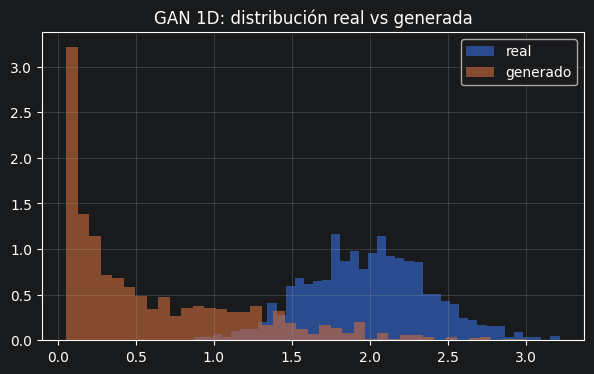

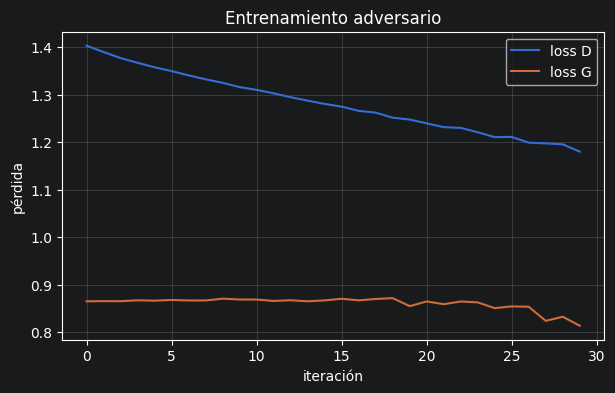

In [11]:
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_STATE)

    class Generator1D(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(1, 16),
                nn.ReLU(),
                nn.Linear(16, 16),
                nn.ReLU(),
                nn.Linear(16, 1)
            )

        def forward(self, z):
            return self.net(z)

    class Discriminator1D(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(1, 16),
                nn.LeakyReLU(0.2),
                nn.Linear(16, 16),
                nn.LeakyReLU(0.2),
                nn.Linear(16, 1)
            )

        def forward(self, x):
            return self.net(x)

    G = Generator1D()
    D = Discriminator1D()

    opt_G = torch.optim.Adam(G.parameters(), lr=0.002)
    opt_D = torch.optim.Adam(D.parameters(), lr=0.002)
    bce = nn.BCEWithLogitsLoss()

    losses_G, losses_D = [], []

    for step in range(30):
        batch_size = 128
        real = 2.0 + 0.4 * torch.randn(batch_size, 1)
        z = torch.randn(batch_size, 1)
        fake = G(z).detach()

        # Entrenamiento del discriminador
        D_real = D(real)
        D_fake = D(fake)
        loss_D = bce(D_real, torch.ones_like(D_real)) + bce(D_fake, torch.zeros_like(D_fake))
        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Entrenamiento del generador
        z = torch.randn(batch_size, 1)
        fake = G(z)
        D_fake = D(fake)
        loss_G = bce(D_fake, torch.ones_like(D_fake))
        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

        losses_G.append(loss_G.item())
        losses_D.append(loss_D.item())

    with torch.no_grad():
        real_samples = 2.0 + 0.4 * torch.randn(1000, 1)
        fake_samples = G(torch.randn(1000, 1))

    plt.figure(figsize=(7, 4))
    plt.hist(real_samples.numpy().ravel(), bins=40, alpha=0.6, density=True, label="real")
    plt.hist(fake_samples.numpy().ravel(), bins=40, alpha=0.6, density=True, label="generado")
    plt.title("GAN 1D: distribución real vs generada")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    plt.figure(figsize=(7, 4))
    plt.plot(losses_D, label="loss D")
    plt.plot(losses_G, label="loss G")
    plt.title("Entrenamiento adversario")
    plt.xlabel("iteración")
    plt.ylabel("pérdida")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

# 10. Problemas de las GANs

Las GANs pueden generar muestras de mucha calidad, pero son difíciles de entrenar.

Problemas frecuentes:

| Problema | Descripción |
|---|---|
| Discriminador demasiado bueno | el generador recibe gradientes casi nulos |
| Mode collapse | el generador ignora parte de $z$ y produce pocas variedades |
| Mode dropping | algunas zonas de la distribución real nunca se generan |
| Entrenamiento inestable | el equilibrio entre $G$ y $D$ es delicado |

Por eso se han propuesto variantes como WGAN, DCGAN, GANs condicionadas, CycleGAN o StyleGAN.

## 10.1 Mode collapse: intuición visual

En un buen generador, diferentes valores de $z$ deberían producir diferentes muestras plausibles. En mode collapse, muchos valores distintos de $z$ terminan produciendo salidas muy parecidas.

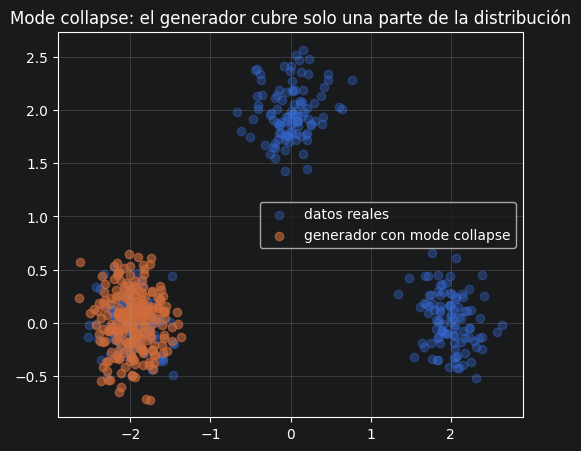

In [12]:
# Ilustración conceptual de cobertura vs mode collapse
real_modes = np.vstack([
    np.random.randn(100, 2) * 0.25 + np.array([-2, 0]),
    np.random.randn(100, 2) * 0.25 + np.array([0, 2]),
    np.random.randn(100, 2) * 0.25 + np.array([2, 0])
])
collapse_samples = np.random.randn(250, 2) * 0.25 + np.array([-2, 0])

plt.figure(figsize=(6, 5))
plt.scatter(real_modes[:, 0], real_modes[:, 1], alpha=0.35, label="datos reales")
plt.scatter(collapse_samples[:, 0], collapse_samples[:, 1], alpha=0.6, label="generador con mode collapse")
plt.title("Mode collapse: el generador cubre solo una parte de la distribución")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 11. Wasserstein GAN

Una **Wasserstein GAN** cambia la función de pérdida para dar una señal de gradiente más útil al generador.

La idea es medir una distancia entre distribuciones de forma más estable que la pérdida original de GAN.

En vez de que el discriminador sea un clasificador probabilístico, se usa un **crítico** que asigna puntuaciones. La pérdida básica se puede escribir como:

$$
L_D = \mathbb{E}[D(G(z))] - \mathbb{E}[D(x)]
$$

$$
L_G = -\mathbb{E}[D(G(z))]
$$

En la versión original se impone una restricción de Lipschitz mediante *weight clipping*.

In [13]:
if TORCH_AVAILABLE:
    # Ejemplo mínimo de cómo serían las pérdidas WGAN en PyTorch
    critic_real_scores = torch.tensor([[1.4], [1.1], [0.9]])
    critic_fake_scores = torch.tensor([[-0.2], [0.1], [-0.4]])

    loss_critic = critic_fake_scores.mean() - critic_real_scores.mean()
    loss_generator = -critic_fake_scores.mean()

    print("WGAN loss critic:", round(loss_critic.item(), 4))
    print("WGAN loss generator:", round(loss_generator.item(), 4))
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

WGAN loss critic: -1.3
WGAN loss generator: 0.1667


<div style="background:rgba(84,130,53,0.14);border-left:5px solid #548235;padding:14px;border-radius:6px;color:inherit">

### Resumen de WGAN

La WGAN intenta mejorar la estabilidad del entrenamiento adversario. Es especialmente importante cuando el discriminador de una GAN clásica se vuelve demasiado bueno y el generador deja de recibir gradientes útiles.

En WGAN se suele hablar de **crítico** en lugar de discriminador, porque no devuelve necesariamente una probabilidad de real/falso.

</div>

# 12. DCGAN y GANs condicionadas

## DCGAN

Una **Deep Convolutional GAN** utiliza capas convolucionales y convoluciones transpuestas para generar imágenes.

Ideas habituales:

- el generador recibe ruido $z$ y aumenta progresivamente la resolución;
- el discriminador reduce progresivamente la resolución;
- se usan convoluciones con stride y convoluciones transpuestas;
- se suele usar BatchNorm;
- el discriminador suele usar Leaky ReLU;
- la salida del generador puede usar `tanh` si las imágenes están normalizadas a $[-1,1]$.

## GAN condicionada

En una GAN condicionada, el generador no solo recibe ruido, sino también una condición $c$:

$$
x = G(z, c)
$$

Ejemplos:

- generar una imagen de una clase concreta;
- transformar una imagen de entrada en otra imagen;
- Pix2Pix: imagen condicionante $\rightarrow$ imagen generada;
- CycleGAN: traducción entre dominios sin pares exactos.

In [14]:
if TORCH_AVAILABLE:
    class TinyDCGANGenerator(nn.Module):
        def __init__(self, z_dim=32, out_channels=1):
            super().__init__()
            self.net = nn.Sequential(
                nn.ConvTranspose2d(z_dim, 64, kernel_size=4, stride=1, padding=0),
                nn.BatchNorm2d(64),
                nn.ReLU(True),
                nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(True),
                nn.ConvTranspose2d(32, out_channels, kernel_size=4, stride=2, padding=1),
                nn.Tanh()
            )

        def forward(self, z):
            return self.net(z)

    G_img = TinyDCGANGenerator(z_dim=32, out_channels=1)
    z = torch.randn(4, 32, 1, 1)
    fake_images = G_img(z)

    print(G_img)
    print("fake_images shape:", fake_images.shape)
else:
    print("Ejemplo no ejecutado porque PyTorch no está disponible.")

TinyDCGANGenerator(
  (net): Sequential(
    (0): ConvTranspose2d(32, 64, kernel_size=(4, 4), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (7): Tanh()
  )
)
fake_images shape: torch.Size([4, 1, 16, 16])


# 13. Ejercicios tipo examen resueltos

En esta sección se recogen ejercicios directamente orientados al estilo de examen.

## Ejercicio 1 — GANs

**Enunciado.** En una GAN, señala qué afirmación es incorrecta:

1. El generador trata de engañar al discriminador durante el entrenamiento.
2. El discriminador es la red que se utiliza una vez entrenada la GAN.
3. Se puede utilizar la pérdida de Wasserstein para evitar la tendencia hacia 0 de los gradientes del generador.
4. El discriminador es un clasificador que permite distinguir ejemplos verdaderos de generados.

### Solución

La afirmación incorrecta es:

> **El discriminador es la red que se utiliza una vez entrenada la GAN.**

Normalmente, una vez entrenada la GAN, la red que se utiliza para generar nuevos ejemplos es el **generador**. El discriminador se usa durante el entrenamiento para proporcionar una señal adversaria.

## Ejercicio 2 — Transfer Learning

**Pregunta.** ¿Por qué tiene sentido reutilizar una CNN entrenada en ImageNet para una tarea con pocas imágenes?

### Solución

Tiene sentido porque las primeras e intermedias capas de una CNN aprenden características generales, como bordes, texturas, patrones y partes de objetos. Estas características pueden ser útiles para muchas tareas visuales distintas.

La estrategia habitual es:

1. cargar un modelo preentrenado;
2. quitar o reemplazar la última capa;
3. congelar el backbone si hay pocos datos;
4. entrenar una nueva cabeza de clasificación;
5. opcionalmente hacer fine-tuning parcial.

## Ejercicio 3 — Multi-task Learning

**Pregunta.** ¿El aprendizaje multi-tarea siempre mejora frente a entrenar modelos separados?

### Solución

No. Puede mejorar cuando las tareas comparten información útil, pero también puede empeorar por transferencia negativa.

Posibles causas:

- las tareas no están suficientemente relacionadas;
- una pérdida domina sobre las demás;
- los gradientes de varias tareas entran en conflicto;
- la red no tiene capacidad suficiente;
- las cabezas de salida están colocadas en una zona inadecuada del modelo.

## Ejercicio 4 — Self-supervised Learning

**Pregunta.** ¿Qué diferencia hay entre aprendizaje supervisado y auto-supervisado?

### Solución

En aprendizaje supervisado, las etiquetas suelen venir dadas por un proceso externo, normalmente humano o procedente de una base de datos etiquetada.

En aprendizaje auto-supervisado, las etiquetas se generan automáticamente a partir de los propios datos. Por ejemplo, se puede rotar una imagen y pedir al modelo que prediga el ángulo de rotación. La tarea sirve para aprender una representación útil sin necesidad de etiquetas manuales.

## Ejercicio 5 — Contrastive Learning

**Pregunta.** ¿Qué significa acercar positivos y alejar negativos?

### Solución

En aprendizaje contrastivo:

- un par positivo son dos vistas distintas del mismo dato o dos datos considerados similares;
- un par negativo son datos distintos que no deberían tener la misma representación.

La pérdida se diseña para aumentar la similitud entre positivos y disminuir la similitud entre negativos. El resultado es un espacio latente donde la distancia tiene significado semántico.

# 14. Resumen final

| Concepto | Idea principal | Palabra clave |
|---|---|---|
| Representación | activaciones internas útiles para resolver una tarea | embedding |
| Representación jerárquica | capas profundas construyen abstracciones crecientes | jerarquía |
| Transfer Learning | reutilizar una representación aprendida en otra tarea | reutilización |
| Multi-task Learning | varias tareas comparten un backbone | representación compartida |
| Self-supervised Learning | etiquetas generadas automáticamente | pretext task |
| Contrastive Learning | acercar positivos y alejar negativos | similitud |
| Domain Adaptation | generalizar entre dominios diferentes | distribución fuente/destino |
| Modelo generativo | aprende a generar ejemplos plausibles | variables latentes |
| GAN | generador contra discriminador | entrenamiento adversario |
| WGAN | mejora la estabilidad usando distancia Wasserstein | crítico |
| DCGAN | GAN convolucional para imágenes | ConvTranspose2d |

<div style="background:rgba(47,85,151,0.12);border-left:5px solid #2f5597;padding:14px;border-radius:6px;color:inherit">

### Checklist de examen

Al terminar este tema deberías poder explicar:

- qué es una representación aprendida;
- por qué las redes profundas aprenden representaciones jerárquicas;
- cuándo usar transfer learning y fine-tuning;
- qué ventajas y riesgos tiene multi-task learning;
- qué es una tarea auto-supervisada;
- cómo funciona el aprendizaje contrastivo;
- qué problema resuelve domain adaptation;
- qué hacen el generador y el discriminador en una GAN;
- por qué la afirmación “se usa el discriminador una vez entrenada la GAN” suele ser falsa;
- qué problemas tienen las GANs y por qué aparece WGAN.

</div>